In [1]:
from typing import TypedDict
class PortfolioState(TypedDict):
    amt_usd: float
    total_usd: float
    total_inr: float

In [2]:
my_obj: PortfolioState = {
    "amt_usd": 1000.0,
    "total_usd": 1500.0,
    "total_inr": 120000.0
}

In [3]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state["total_usd"] = state["amt_usd"] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state["total_inr"] = state["total_usd"] * 75
    return state

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("calc_total", calc_total)
builder.add_node("convert_to_inr", convert_to_inr)
builder.add_edge(START, "calc_total")
builder.add_edge("calc_total", "convert_to_inr")
builder.add_edge("convert_to_inr", END)

graph = builder.compile()


d:\new stuff\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


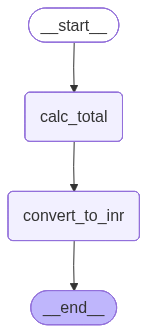

In [5]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))